In [1]:
from loader import * 
from scripts.processing import *
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [5]:
exp_data_folder = Path("../data")
dataset = DatasetGrail(exp_data_folder, "../config.xlsx")

In [8]:
index = dataset.create_index()
dataset_14 = dataset.get_subset(
    task=["walking"], speed = [1.4]
)

In [9]:
dataset

,id,speed,measurement,task
0,S01,0.0,static,static
1,S01,1.0,walking1,walking
2,S01,1.6,walking2,walking
3,S01,1.2,walking3,walking
4,S01,1.8,walking4,walking
...,...,...,...,...
85,S15,1.0,walking1,walking
86,S15,1.8,walking2,walking
87,S15,1.2,walking3,walking
88,S15,1.6,walking4,walking


# Plot and store single files

In [46]:
grf = dataset_14[2].grf_data
speed = dataset_14[2].beltspeed_data
fs_speed = 1/np.diff(speed.index).mean()
speed = filter_data(speed, fs = fs_speed, fc=30)

In [47]:
cycles = average_cycles(grf.GRF_y_1, grf.GRF_y_2, grf.GRF_x_1, grf.GRF_x_2, speed.left, speed.right)

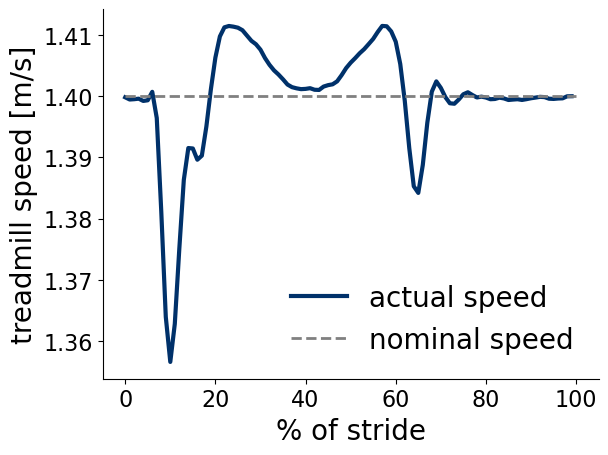

In [48]:
plt.figure()
plt.plot(cycles.speedL, linewidth=3, color="#00316A", label = "actual speed")
plt.xlabel("% of stride", fontsize=20)
plt.ylabel("treadmill speed [m/s]", fontsize = 20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.hlines(1.4, 0, 100, color ="gray", linestyle="dashed", linewidth = 2, label = "nominal speed" )
plt.legend(loc = 'lower right', fontsize = 20, frameon=False)
sns.despine()
plt.savefig("../plots_paper/example.pdf", bbox_inches='tight')

# load all

In [14]:
dataset = dataset.get_subset(
    task=["walking"],
)

## per speed

In [15]:
speeds = list(dataset.index.speed.unique())
speeds

[1.0, 1.6, 1.2, 1.8, 1.4]

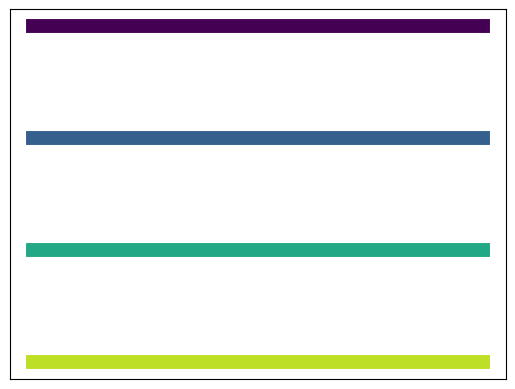

In [66]:
cmap = plt.colormaps["viridis"]
colors = cmap([0.9, 0.6, 0.3, 0.0])

for i, color in enumerate(colors):
    plt.plot([0, 1], [i, i], lw=10, color=color)

plt.yticks([])
plt.xticks([])
plt.show()

cmap_discrete = colors

In [32]:
#cmap_discrete = sns.color_palette("viridis", as_cmap=True)


#cmap_discrete

[(0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426)]

not in data
not in data
not in data
not in data
not in data
not in data
not in data
not in data
not in data
not in data
not in data


C:\Users\Sophie Fleischmann\AppData\Local\Temp\ipykernel_11640\2348092975.py:25: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.lineplot(data=df_long, x="time", y="value", hue="mass", palette=cmap_discrete, legend="full", linewidth = 3)


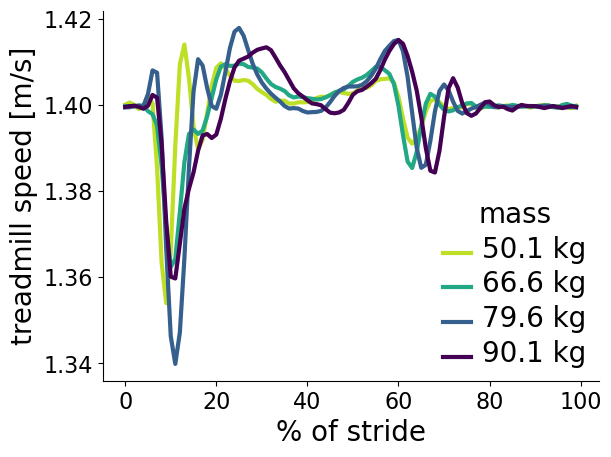

In [67]:
plt.figure()
#i = 1
for speed in speeds[4:]:
    #plt.subplot(3,2,i)
    subset = dataset.get_subset(speed = [speed])
    speed_values = []
    masses = []
    for p in subset:
        grf = p.grf_data
        speed = p.beltspeed_data
        fs_speed = 1/np.diff(speed.index).mean()
        speed_filtered = filter_data(speed, fs = fs_speed, fc=30)
        cycles = average_cycles(grf.GRF_y_1, grf.GRF_y_2, grf.GRF_x_1, grf.GRF_x_2, speed_filtered.left, speed_filtered.right)
        
        if p.mass not in [50.11, 66.61, 79.56, 90.14]:
            print('not in data')
            continue
        speed_values.append(cycles.speedL)
        masses.append(p.mass)
    df = pd.DataFrame(speed_values)
    df['mass'] = masses
   
    df_long = df.melt(id_vars="mass", var_name="time", value_name="value")
    df_long["time"] = pd.to_numeric(df_long["time"])
    ax = sns.lineplot(data=df_long, x="time", y="value", hue="mass", palette=cmap_discrete, legend="full", linewidth = 3)
    #ax.set_yticks([-0.04, -0.02, 0, 0.02])
    handles, labels = ax.get_legend_handles_labels()

    labels = [f"{float(l):.1f} kg" if l != "mass" else l for l in labels]

    ax.legend(handles, labels, title='mass', frameon=False)
    ax.set_yticks([1.34, 1.36, 1.38, 1.4, 1.42])
    plt.ylabel('treadmill speed [m/s]', fontsize = 20)
    plt.xlabel('% of stride', fontsize =20 )
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.setp(ax.get_legend().get_texts(), fontsize='20') # for legend text
    plt.setp(ax.get_legend().get_title(), fontsize='20')
    
   
    sns.despine()
   # plt.show()
    plt.savefig("../plots_paper/multiple_persons.pdf", bbox_inches='tight')
  
        
    

## compute the max deviations from the desired speed in %

In [12]:
for p in dataset:
    grf = p.grf_data
    speed = p.beltspeed_data
    fs_speed = 1/np.diff(speed.index).mean()
    speed_filtered = filter_data(speed, fs = fs_speed, fc=30)
    cycles = average_cycles(grf.GRF_y_1, grf.GRF_y_2, grf.GRF_x_1, grf.GRF_x_2, speed_filtered.left, speed_filtered.right)
    des_speed = p.index.speed[0]
    decrease  = ((des_speed - min(cycles.speedL))/des_speed)*100
    print(decrease)

2.7231414976402912
3.162732809218874
2.6769942017922377
3.1402786348065557
2.783191038123618
1.951211874645442
2.5376057952557485
2.1382595566397895
1.5994406069444838
2.352529721775687
2.742137139185652
3.3616131821777167
3.102318232349839
3.80766874433854
3.0382345276920115
3.5760848957833935
4.618572894689462
4.199275852235433
4.293876137557432
5.031293274845576
3.1315438797536954
4.5348544706604255
4.655676666194444
4.0066578044859655
3.855299399894485
4.151959962739571
4.184817117502262
4.100118896142257
4.167262952734915
3.496739976559249
2.759430855512812
2.854802562452334
3.285227582097277
3.3893674735102355
3.4915216321207296
2.4022726295225505
2.5956375995537426
2.847976288308601
2.6893110176453097
3.0776553635326116
3.5737529510688426
3.957949606398323
3.8383534508856973
3.890948256164157
3.883646457607875
3.6782354687823093
4.357936639198987
4.7680111675426256
4.560402721242659
4.7257487962900635
3.257145932228489
3.722250342334125
3.186419548883268
3.6429956384861906
3.383

## per person

In [41]:
persons = list(dataset.index.id.unique())
persons

['S01',
 'S02',
 'S03',
 'S04',
 'S05',
 'S06',
 'S07',
 'S08',
 'S09',
 'S10',
 'S11',
 'S12',
 'S13',
 'S14',
 'S15']

In [42]:
import matplotlib

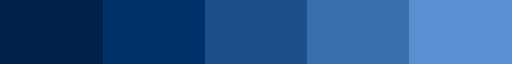

In [43]:
cmap_discrete = matplotlib.colors.ListedColormap(
    name="discrete",
colors = [
    "#00224A",
    "#00316A",
    "#1C4F8C",
    "#3A6FAF",
    "#5A90D1"
]
)
cmap_discrete



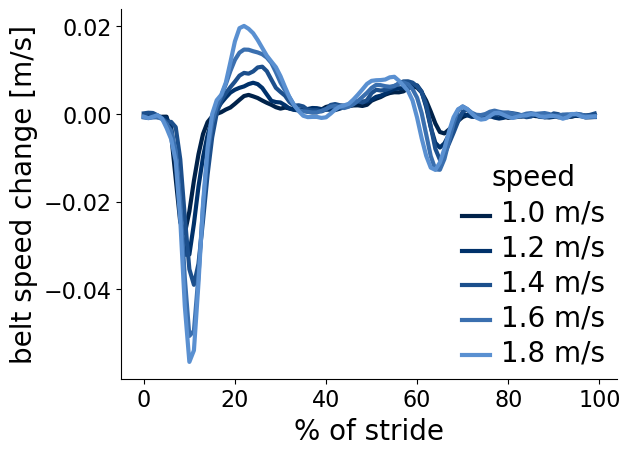

In [44]:
#plt.figure(figsize=(14,10))
i = 1
for p in persons[:1]:
    #plt.subplot(3,3,i)
    plt.figure()
    subset = dataset.get_subset(id = [p])
    speed_values = []
    speeds = []
    for p in subset:
        grf = p.grf_data
        speed = p.beltspeed_data
        fs_speed = 1/np.diff(speed.index).mean()
        speed_filtered = filter_data(speed, fs = fs_speed, fc=30)
        cycles = average_cycles(grf.GRF_y_1, grf.GRF_y_2, grf.GRF_x_1, grf.GRF_x_2, speed_filtered.left, speed_filtered.right)
        speed_values.append(cycles.speedL - p.index.speed[0])
        speeds.append(p.index.speed[0])
    df = pd.DataFrame(speed_values)
    df['speed'] = speeds
    df_long = df.melt(id_vars="speed", var_name="time", value_name="value")
    df_long["time"] = pd.to_numeric(df_long["time"])
    ax = sns.lineplot(data=df_long, x="time", y="value", hue="speed", palette=cmap_discrete, legend="full", linewidth=3)
    ax.set_yticks([-0.04, -0.02, 0, 0.02])
    handles, labels = ax.get_legend_handles_labels()

    labels = [f"{float(l):.1f} m/s" if l != "mass" else l for l in labels]

    ax.legend(handles, labels, title='speed', frameon=False)
    plt.ylabel('belt speed change [m/s]', fontsize = 20)
    plt.xlabel('% of stride', fontsize =20 )
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.setp(ax.get_legend().get_texts(), fontsize='20') # for legend text
    plt.setp(ax.get_legend().get_title(), fontsize='20')
    i+=1
    sns.despine()
    plt.savefig("../plots_paper/allspeeds.pdf", bbox_inches='tight')

    
#plt.figure()


#plt.legend(loc = 'lower right', fontsize = 20)



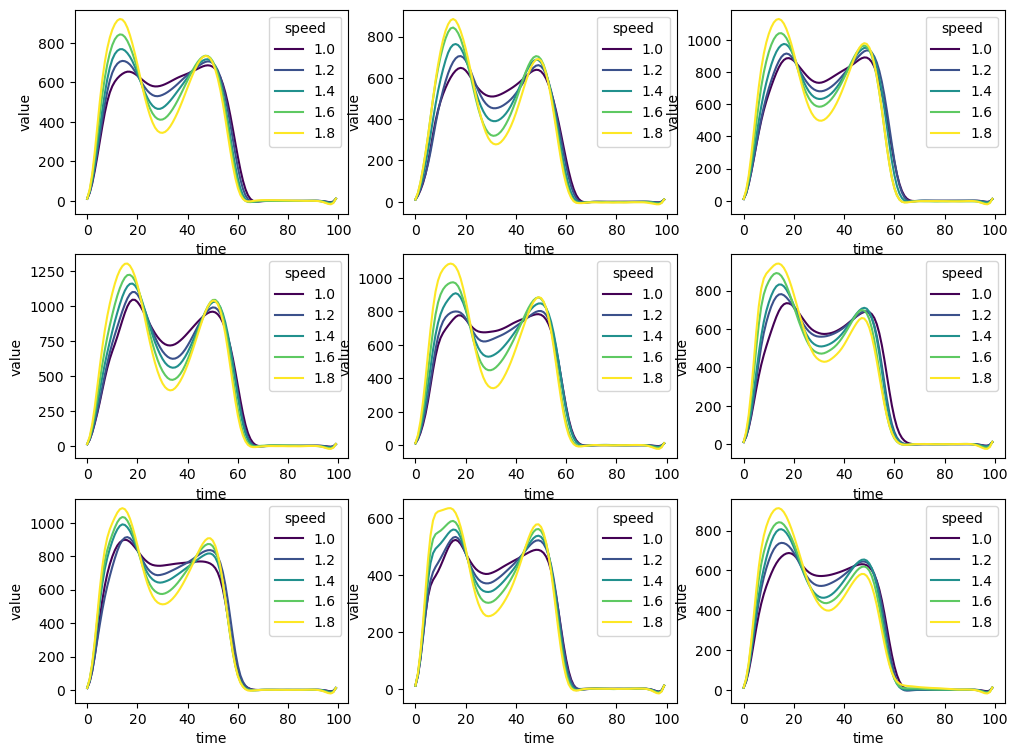

In [12]:
plt.figure(figsize=(12,9))
i = 1
for p in persons:
    plt.subplot(3,3,i)
    subset = dataset.get_subset(id = [p])
    speed_values = []
    speeds = []
    for p in subset:
        grf = p.grf_data
        speed = p.beltspeed_data
        fs_speed = 1/np.diff(speed.index).mean()
        speed_filtered = filter_data(speed, fs = fs_speed)
        cycles = average_cycles(grf.GRF_y_1, grf.GRF_y_2, grf.GRF_x_1, grf.GRF_x_2, speed_filtered.left, speed_filtered.right)
        speed_values.append(cycles.FyL)
        speeds.append(p.index.speed[0])
    df = pd.DataFrame(speed_values)
    df['speed'] = speeds
    df_long = df.melt(id_vars="speed", var_name="time", value_name="value")
    df_long["time"] = pd.to_numeric(df_long["time"])
    sns.lineplot(data=df_long, x="time", y="value", hue="speed", palette="viridis", legend="full")
    i+=1

In [23]:
signals = {
    "GRFy": "FyL",
    "GRFx": "FxL",
    "Speed": "speedL"   # change this to the actual column name in cycles
}

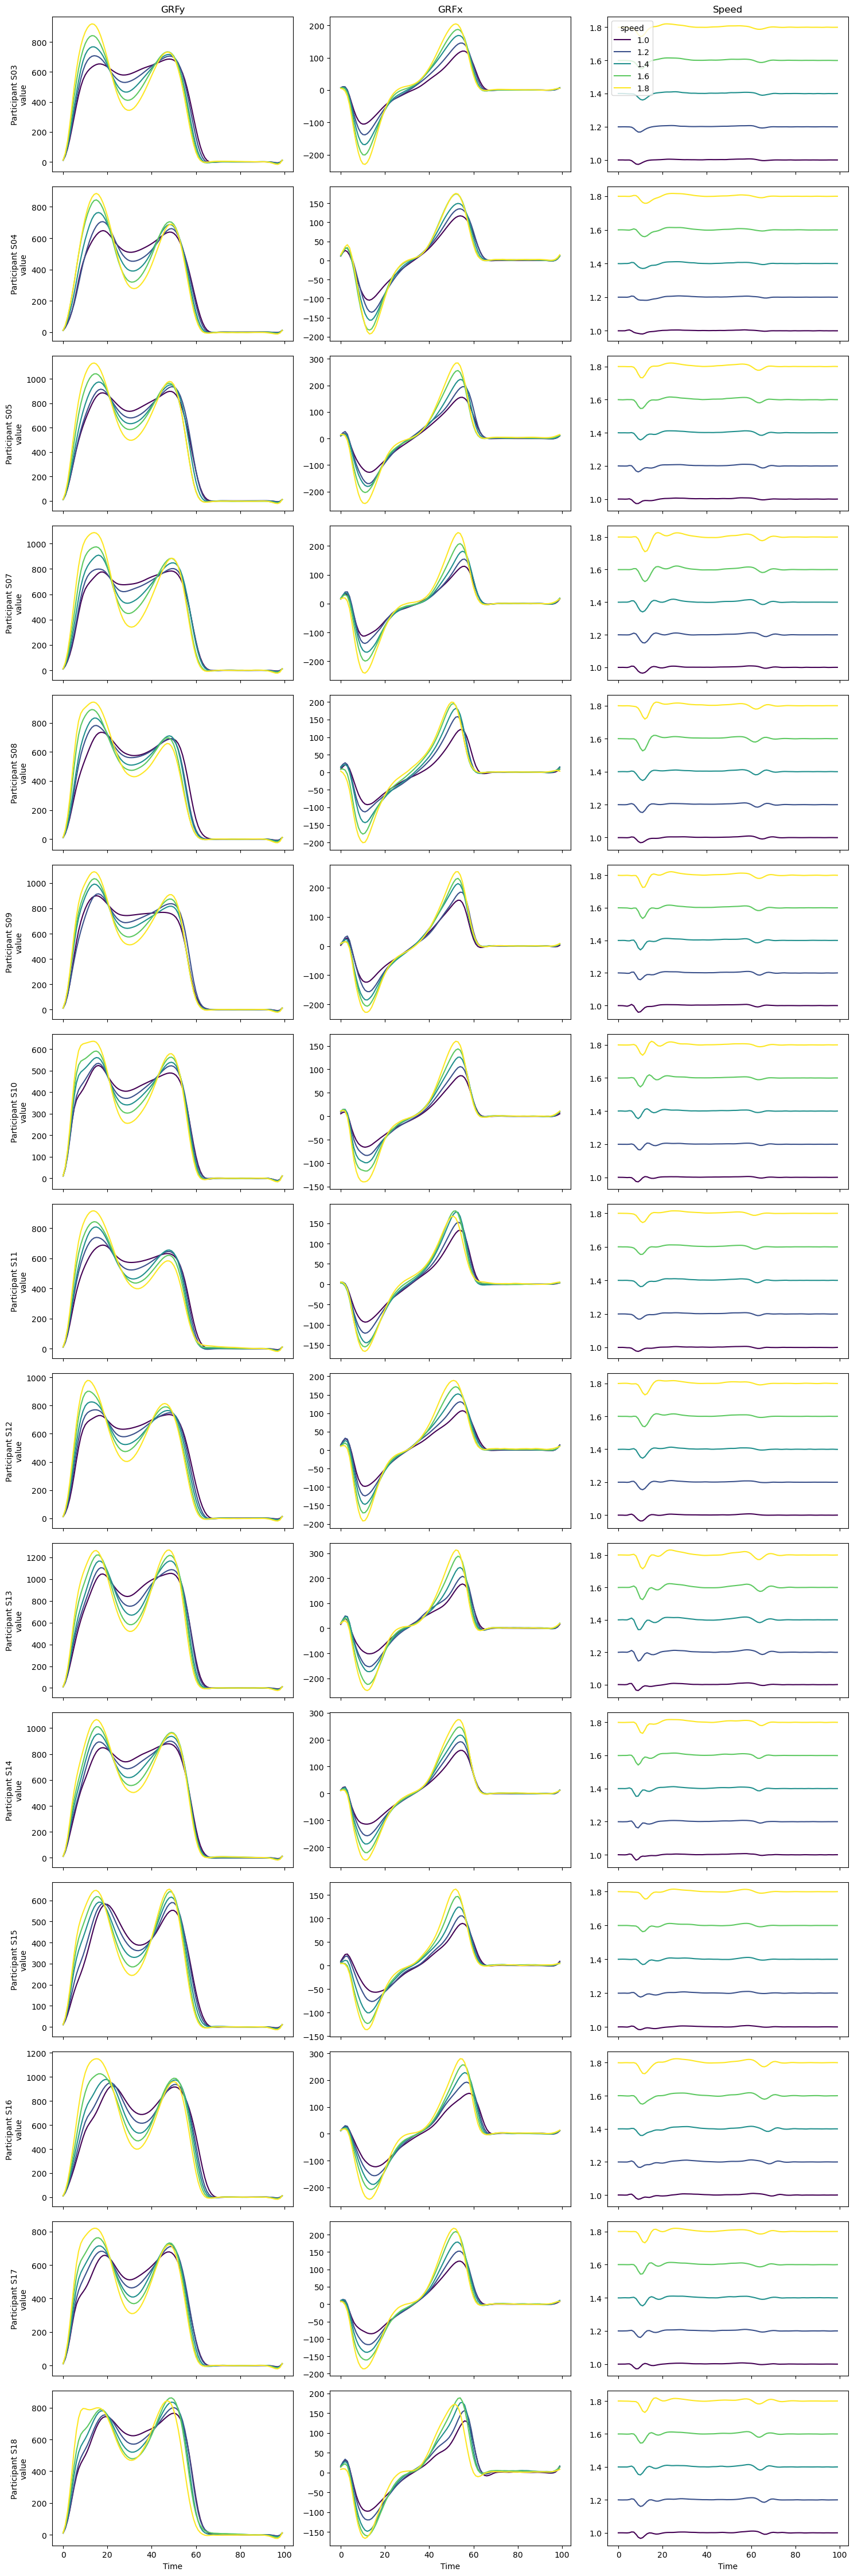

In [24]:
fig, axes = plt.subplots(
    nrows=len(persons),
    ncols=3,
    figsize=(15, 3 * len(persons)),
    sharex=True
)

for row, person in enumerate(persons):

    subset = dataset.get_subset(id=[person])

    all_data = []

    for trial in subset:
        grf = trial.grf_data
        speed = trial.beltspeed_data

        fs_speed = 1 / np.diff(speed.index).mean()
        speed_filtered = filter_data(speed, fs=fs_speed, fc=30)

        cycles = average_cycles(
            grf.GRF_y_1, grf.GRF_y_2,
            grf.GRF_x_1, grf.GRF_x_2,
            speed_filtered.left, speed_filtered.right
        )

        trial_speed = trial.index.speed[0]

        for signal_name, cycle_attr in signals.items():
            values = getattr(cycles, cycle_attr)

            df_tmp = pd.DataFrame({
                "time": np.arange(len(values)),
                "value": values,
                "speed": trial_speed,
                "signal": signal_name
            })

            all_data.append(df_tmp)

    df_long = pd.concat(all_data, ignore_index=True)

    for col, signal_name in enumerate(signals.keys()):
        ax = axes[row, col]

        sns.lineplot(
            data=df_long[df_long["signal"] == signal_name],
            x="time",
            y="value",
            hue="speed",
            palette="viridis",
            legend="full" if row == 0 and col == 2 else False,
            ax=ax
        )

        if row == 0:
            ax.set_title(signal_name)

        if col == 0:
            ax.set_ylabel(f"Participant {person}\nvalue")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

## compute durations

In [12]:
durations = np.zeros((15,5))
for i, p in enumerate(persons):
    print('participant ', i)
    for j, s in enumerate(speeds):
        trial = dataset.get_subset(id=p, speed=s)
    

        cycles, dur = get_data(trial)
        dur = np.round(dur, 3)

        
        durations[i,j] = dur

participant  0
participant  1
participant  2
participant  3
participant  4
participant  5
participant  6
participant  7
participant  8
participant  9
participant  10
participant  11
participant  12
participant  13
participant  14


In [15]:
durations = pd.DataFrame(durations, index = persons, columns = speeds)
durations = durations.reindex(
    sorted(durations.columns.astype(float)),
    axis=1
)

In [17]:
durations

,1.0,1.2,1.4,1.6,1.8
S03,1.226,1.156,1.101,1.033,0.992
S04,1.323,1.236,1.119,1.053,0.984
S05,1.323,1.236,1.125,1.055,0.985
S07,1.159,1.034,0.967,0.910,0.876
S08,1.045,0.984,0.945,0.891,0.852
S09,1.244,1.209,1.113,1.027,0.965
S10,1.141,1.096,1.070,1.028,0.969
S11,1.230,1.118,1.061,0.995,0.933
S12,1.175,1.110,1.051,0.988,0.943
S13,1.288,1.161,1.068,1.025,0.967
